# Input Segmentation

You’ve read Laube and Purves (2011) about segmenting trajectories. In the paper, the authors define *“static”* fixes as *“those whose average Euclidean distance to other fixes inside a temporal window v is less than some threshold d”*, as illustrated in Figure 16.1

**Innerhalb dieses Moving Windows $v$ wird der Abstand eines Punktes zu jedem anderen Punkt im Fenster gemessen.** Dies nennt man Segmentierung --> damit werden wir "Rauschen" los, also jene Punkte, welche eine Distanzschwelle unterschreiten.

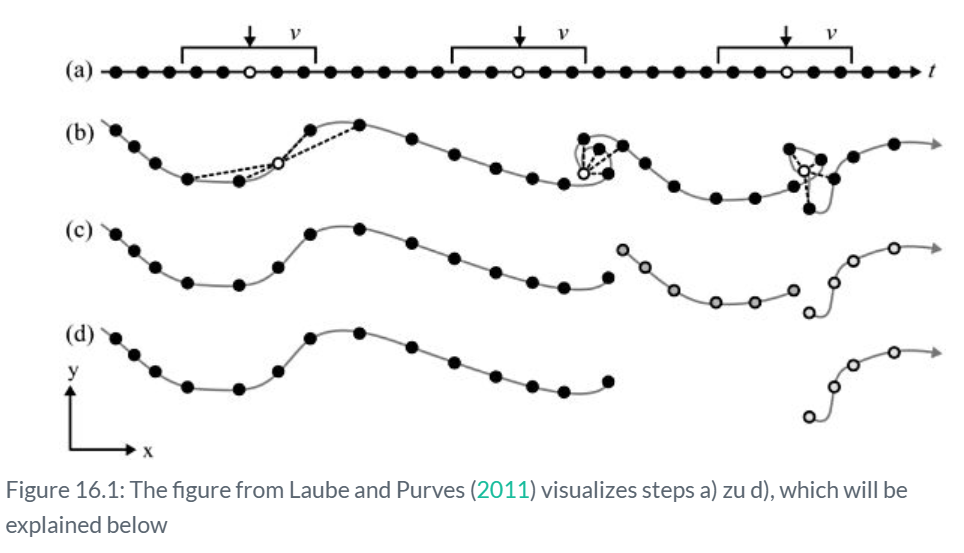

In [1]:
library(IRdisplay)
display_png(file = "Data/fig16.png", width = 600)

1. Specify a temporal windows $v$ for in which to measure Euclidean distances.
2. Measure the distance from every point to every other point within this temporal window $v$.
3. Remove “static points”: These are points where the average distance is less than a given threshold. This segments the trajectory into subtrajectories.
4. Now remove short subtrajectories: These are trajectories with a short duration (whereas “short” is tbd).

We will demonstrate implementing this method on the wild boar **“Sabi”**, restricting ourselves to a couple of tracking days. Your task will be to understand this implementation and apply it to your own movement data.

Copy the wild boar data you downloaded last week (wildschwein_BE_2056.csv) to your project folder. **Transform** the data into an `sf` object, **filter** for the wild boar Sabi and a datetime between “2015-07-01” and “2015-07-03”.

## Daten einlesen & Filtern

In [2]:
library(tidyverse)

wildschwein <- read_delim("Data/wildschwein_BE_2056.csv", ",")

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 51246 Columns: 6
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): TierID, TierName
dbl  (3): CollarID, E, N
dttm (1): DatetimeUTC

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
library("sf")
library("dplyr")

# Careful! What Timezone is assumed?
sabi <- wildschwein %>%
    st_as_sf(coords = c("E", "N"), crs = 2056, remove = FALSE) %>%
    filter(
      TierName == "Sabi", 
      DatetimeUTC >= "2015-07-01", DatetimeUTC < "2015-07-03")

Linking to GEOS 3.13.1, GDAL 3.11.0, PROJ 9.6.0; sf_use_s2() is TRUE



In [4]:
head(sabi)

Registered S3 method overwritten by 'geojsonsf':
  method        from   
  print.geojson geojson



TierID,TierName,CollarID,DatetimeUTC,E,N,geometry
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<POINT [m]>
002A,Sabi,12275,2015-06-30 22:00:13,2569972,1205366,POINT (2569972 1205366)
002A,Sabi,12275,2015-06-30 22:16:06,2569975,1205637,POINT (2569975 1205637)
002A,Sabi,12275,2015-06-30 22:30:19,2570266,1205857,POINT (2570266 1205857)
002A,Sabi,12275,2015-06-30 22:45:13,2570208,1205913,POINT (2570208 1205913)
002A,Sabi,12275,2015-06-30 23:00:10,2570247,1205731,POINT (2570247 1205731)
002A,Sabi,12275,2015-06-30 23:15:17,2570512,1205279,POINT (2570512 1205279)


## Punkte Visualisieren

In [5]:
library(tmap)

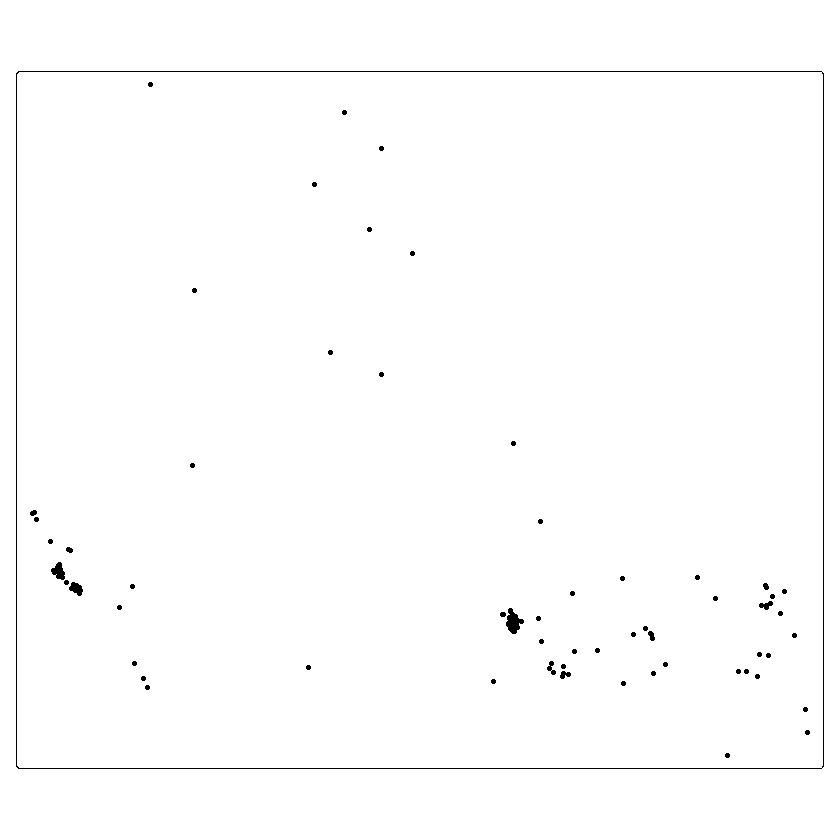

In [6]:
tm_shape(sabi$geometry) + 
  tm_dots()

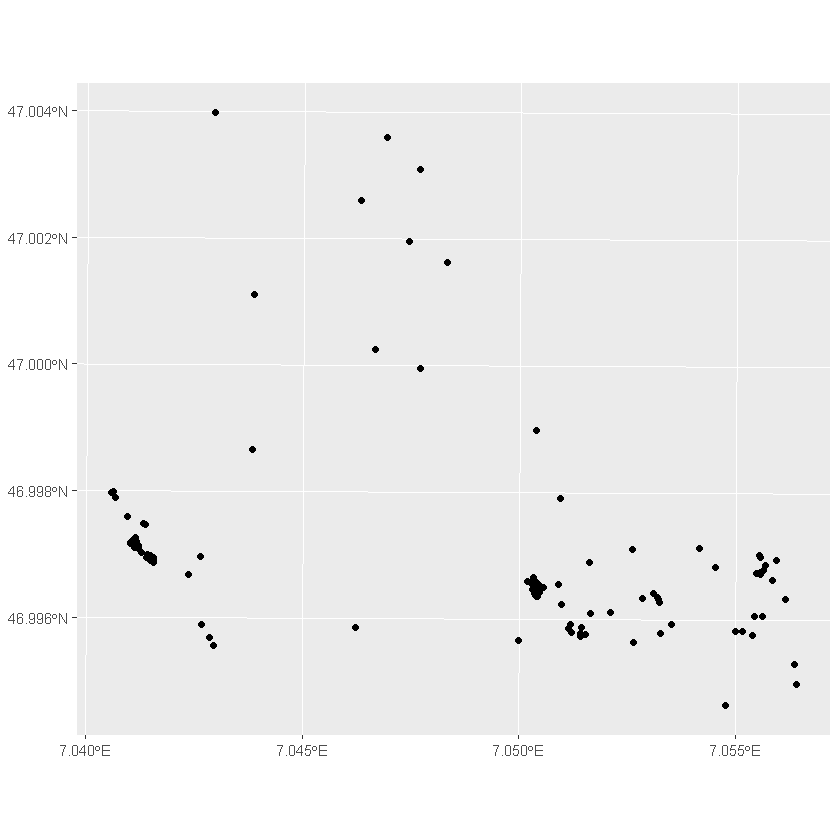

In [7]:
ggplot(sabi) +
    geom_sf()

## Linien erstellen & visualisieren

In [8]:
sabi_line <- sabi %>% 
  # dissolve to a MULTIPOINT:
  summarise(do_union = FALSE) %>%
  st_cast("LINESTRING")

In [9]:
head(sabi_line)

geometry
<LINESTRING [m]>
LINESTRING (2569972 1205366...


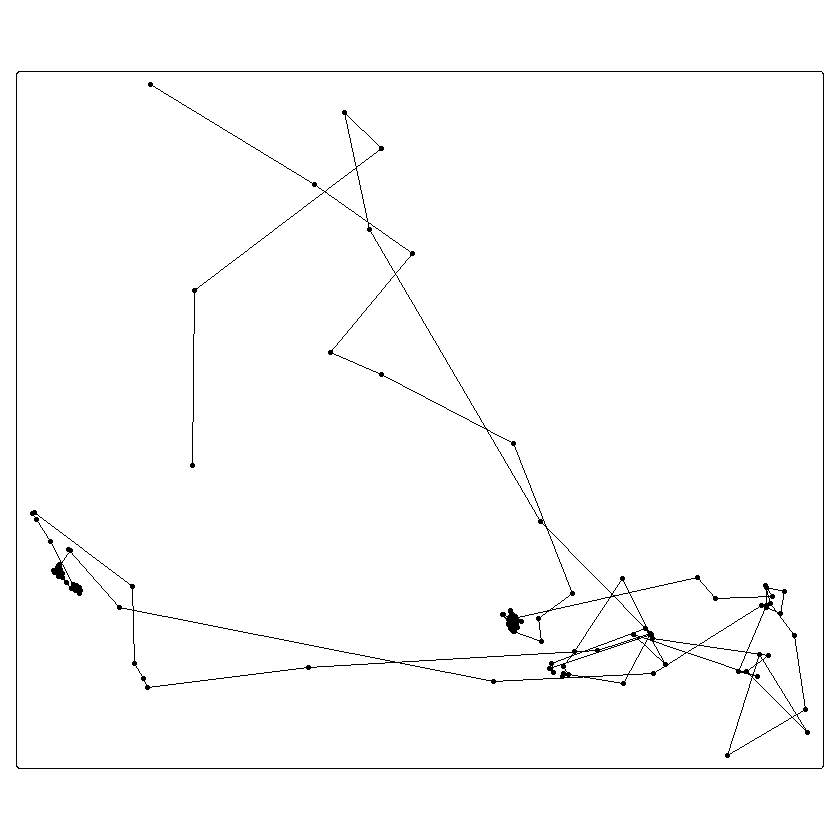

In [10]:
tm_shape(sabi_line) +
  tm_lines() +
  tm_shape(sabi) + 
  tm_dots()

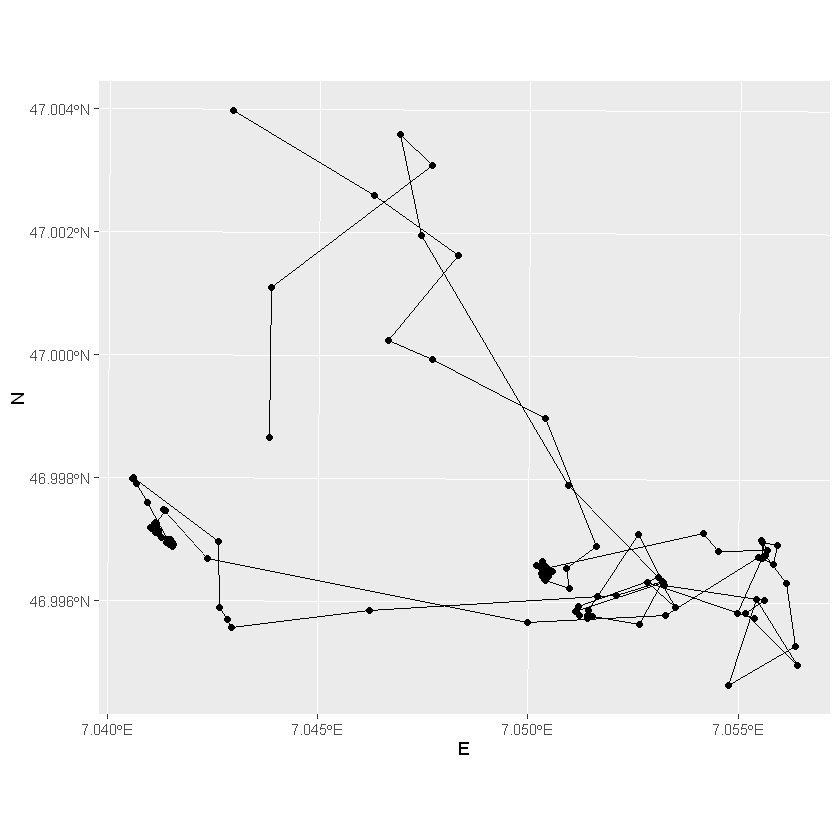

In [11]:
# Hier abgekürzt: ohne zuerst die Linie zu berechnen!

ggplot(sabi) +
    geom_sf() +
    geom_path(aes(E, N)) # geom_path verbindet die Punkte entlang der Reihenfolge im Pfad

## 1. Specify a temporal window 
In the above dataset, the sampling interval is 15 minutes. If we take a temporal window of 60 minutes, that would mean including 4 fixes. We need to calculate the following Euclidean distances (pos representing single location):

- `pos[n-2]` to `pos[n]`
- `pos[n-1]` to `pos[n]`
- `pos[n]` to `pos[n+1]`
- `pos[n]` to `pos[n+2]`

In [12]:
head(sabi)

TierID,TierName,CollarID,DatetimeUTC,E,N,geometry
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<POINT [m]>
002A,Sabi,12275,2015-06-30 22:00:13,2569972,1205366,POINT (2569972 1205366)
002A,Sabi,12275,2015-06-30 22:16:06,2569975,1205637,POINT (2569975 1205637)
002A,Sabi,12275,2015-06-30 22:30:19,2570266,1205857,POINT (2570266 1205857)
002A,Sabi,12275,2015-06-30 22:45:13,2570208,1205913,POINT (2570208 1205913)
002A,Sabi,12275,2015-06-30 23:00:10,2570247,1205731,POINT (2570247 1205731)
002A,Sabi,12275,2015-06-30 23:15:17,2570512,1205279,POINT (2570512 1205279)


## 2. Measure the distance to every point within 
We can use the function **`distance_by_element`** from week 2 in combination with `lead()` and `lag()` to calculate the Euclidean distance. For example, to create the necessary offset of *n-2*, we use `lag(x, 2)`. For each offset, we create one individual column.

`lead()` and `lag()` return **a vector of the same length as the input**, just **offset by a specific number of values** (default is 1). 

- **`lead()`** ersetzt die erste(n) Zahl(en) durch `NA` --> schiebt die NA nach hinten
- **`lag()`** ersetzt die letzte(n) Zahl(en) durch `NA` --> schiebt die NA nach vorne
- `n =` definiert: wie viele Zahlen sollen ersetzt werden
- `default =` definiert: durch was sollen sie ersetzt werden


Jetzt schreiben wir eine Funktion:

In [13]:
distance_by_element <- function(later, now) {
  as.numeric(
    st_distance(later, now, by_element = TRUE)
  )
}

In [14]:
sabi = sabi %>% mutate(
    nMinus2 = distance_by_element(lag(geometry, n = 2), geometry))
head(sabi)

TierID,TierName,CollarID,DatetimeUTC,E,N,geometry,nMinus2
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<POINT [m]>,<dbl>
002A,Sabi,12275,2015-06-30 22:00:13,2569972,1205366,POINT (2569972 1205366),NA
002A,Sabi,12275,2015-06-30 22:16:06,2569975,1205637,POINT (2569975 1205637),NA
002A,Sabi,12275,2015-06-30 22:30:19,2570266,1205857,POINT (2570266 1205857),572.9307
002A,Sabi,12275,2015-06-30 22:45:13,2570208,1205913,POINT (2570208 1205913),361.4587
002A,Sabi,12275,2015-06-30 23:00:10,2570247,1205731,POINT (2570247 1205731),127.2864
002A,Sabi,12275,2015-06-30 23:15:17,2570512,1205279,POINT (2570512 1205279),702.7514


In [15]:
sabi = sabi %>% mutate(
    nMinus2 = distance_by_element(lag(geometry, n = 2), geometry),
    nMinus1 = distance_by_element(lag(geometry, n = 1), geometry))
head(sabi)

TierID,TierName,CollarID,DatetimeUTC,E,N,geometry,nMinus2,nMinus1
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<POINT [m]>,<dbl>,<dbl>
002A,Sabi,12275,2015-06-30 22:00:13,2569972,1205366,POINT (2569972 1205366),NA,NA
002A,Sabi,12275,2015-06-30 22:16:06,2569975,1205637,POINT (2569975 1205637),NA,271.3875
002A,Sabi,12275,2015-06-30 22:30:19,2570266,1205857,POINT (2570266 1205857),572.9307,365.2194
002A,Sabi,12275,2015-06-30 22:45:13,2570208,1205913,POINT (2570208 1205913),361.4587,80.5060
002A,Sabi,12275,2015-06-30 23:00:10,2570247,1205731,POINT (2570247 1205731),127.2864,185.8835
002A,Sabi,12275,2015-06-30 23:15:17,2570512,1205279,POINT (2570512 1205279),702.7514,523.8310


In [16]:
sabi = sabi %>% mutate(
    nMinus2 = distance_by_element(lag(geometry, n = 2), geometry), # hier lag
    nMinus1 = distance_by_element(lag(geometry, n = 1), geometry),
    nPlus1 = distance_by_element(lead(geometry, n = 1), geometry), # hier lead
    nPlus2 = distance_by_element(lead(geometry, n = 2), geometry))
head(sabi)

TierID,TierName,CollarID,DatetimeUTC,E,N,geometry,nMinus2,nMinus1,nPlus1,nPlus2
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<POINT [m]>,<dbl>,<dbl>,<dbl>,<dbl>
002A,Sabi,12275,2015-06-30 22:00:13,2569972,1205366,POINT (2569972 1205366),NA,NA,271.3875,572.9307
002A,Sabi,12275,2015-06-30 22:16:06,2569975,1205637,POINT (2569975 1205637),NA,271.3875,365.2194,361.4587
002A,Sabi,12275,2015-06-30 22:30:19,2570266,1205857,POINT (2570266 1205857),572.9307,365.2194,80.5060,127.2864
002A,Sabi,12275,2015-06-30 22:45:13,2570208,1205913,POINT (2570208 1205913),361.4587,80.5060,185.8835,702.7514
002A,Sabi,12275,2015-06-30 23:00:10,2570247,1205731,POINT (2570247 1205731),127.2864,185.8835,523.8310,765.6433
002A,Sabi,12275,2015-06-30 23:15:17,2570512,1205279,POINT (2570512 1205279),702.7514,523.8310,246.7127,228.9568


Now we want to **calculate the mean distance of `nMinus2`, `nMinus1`, `nPlus1`, `nPlus2` for each row**. Since we want the mean value per Row, we have to explicitly specify this before mutate() with the function **`rowwise()`**. To remove this rowwise-grouping, we end the operation with **`ungroup()`**.

Note that for the first two positions, we cannot calculate a stepMean since there is no Position *n-2* for these positions. This is also true for the last to positions (lacking a position *n+2*).

In [17]:
sabi = sabi %>% 
    rowwise () %>% # sonst kommt überall NA
    mutate(
    stepMean = mean(c(nMinus2, nMinus1, nPlus1, nPlus2), na.rm = FALSE)) %>% 
    ungroup()  # mit rowwise(() müssen wir wieder ungroupen!
head(sabi)

TierID,TierName,CollarID,DatetimeUTC,E,N,geometry,nMinus2,nMinus1,nPlus1,nPlus2,stepMean
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<POINT [m]>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
002A,Sabi,12275,2015-06-30 22:00:13,2569972,1205366,POINT (2569972 1205366),NA,NA,271.3875,572.9307,NA
002A,Sabi,12275,2015-06-30 22:16:06,2569975,1205637,POINT (2569975 1205637),NA,271.3875,365.2194,361.4587,NA
002A,Sabi,12275,2015-06-30 22:30:19,2570266,1205857,POINT (2570266 1205857),572.9307,365.2194,80.5060,127.2864,286.4856
002A,Sabi,12275,2015-06-30 22:45:13,2570208,1205913,POINT (2570208 1205913),361.4587,80.5060,185.8835,702.7514,332.6499
002A,Sabi,12275,2015-06-30 23:00:10,2570247,1205731,POINT (2570247 1205731),127.2864,185.8835,523.8310,765.6433,400.6610
002A,Sabi,12275,2015-06-30 23:15:17,2570512,1205279,POINT (2570512 1205279),702.7514,523.8310,246.7127,228.9568,425.5630


## 3. Remove “static points”

We can now determine if an animal is moving or not by specifying a threshold distance on `stepMean`. In our example, we use the mean value as a **threshold**: Positions with distances below this value are considered static.

In [18]:
treshold = mean(sabi$stepMean, na.rm = TRUE)

In [19]:
treshold

[1] 58.6585

In [20]:
sabi <- sabi %>%
    mutate(static = stepMean < treshold)
head(sabi)

TierID,TierName,CollarID,DatetimeUTC,E,N,geometry,nMinus2,nMinus1,nPlus1,nPlus2,stepMean,static
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<POINT [m]>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
002A,Sabi,12275,2015-06-30 22:00:13,2569972,1205366,POINT (2569972 1205366),NA,NA,271.3875,572.9307,NA,NA
002A,Sabi,12275,2015-06-30 22:16:06,2569975,1205637,POINT (2569975 1205637),NA,271.3875,365.2194,361.4587,NA,NA
002A,Sabi,12275,2015-06-30 22:30:19,2570266,1205857,POINT (2570266 1205857),572.9307,365.2194,80.5060,127.2864,286.4856,FALSE
002A,Sabi,12275,2015-06-30 22:45:13,2570208,1205913,POINT (2570208 1205913),361.4587,80.5060,185.8835,702.7514,332.6499,FALSE
002A,Sabi,12275,2015-06-30 23:00:10,2570247,1205731,POINT (2570247 1205731),127.2864,185.8835,523.8310,765.6433,400.6610,FALSE
002A,Sabi,12275,2015-06-30 23:15:17,2570512,1205279,POINT (2570512 1205279),702.7514,523.8310,246.7127,228.9568,425.5630,FALSE


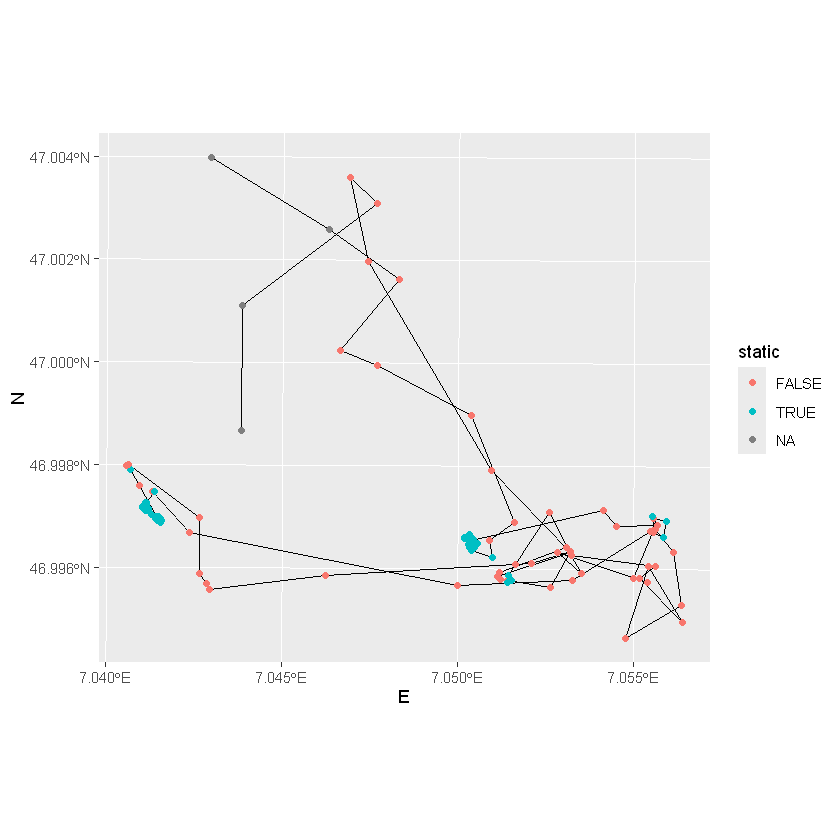

In [21]:
ggplot(sabi) +
    geom_path(aes(E, N)) +
    geom_sf(aes(color = static))

In [22]:
# filter out static points

sabi_filter <- sabi %>%
    filter(!static)

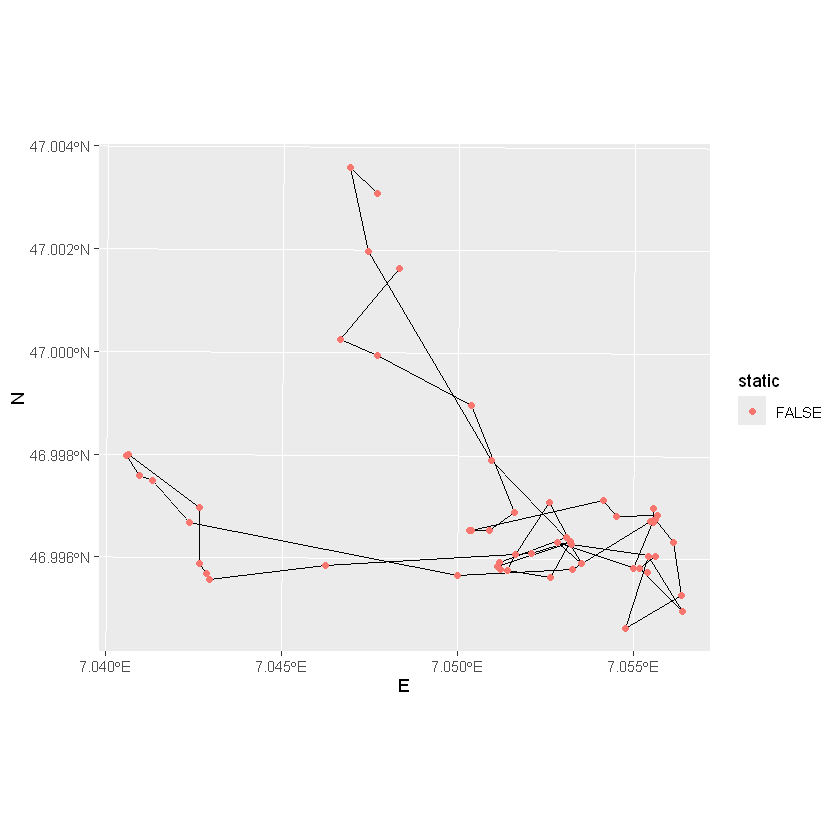

In [23]:
ggplot(sabi_filter) +
    geom_path(aes(E, N)) +
    geom_sf(aes(color = static))

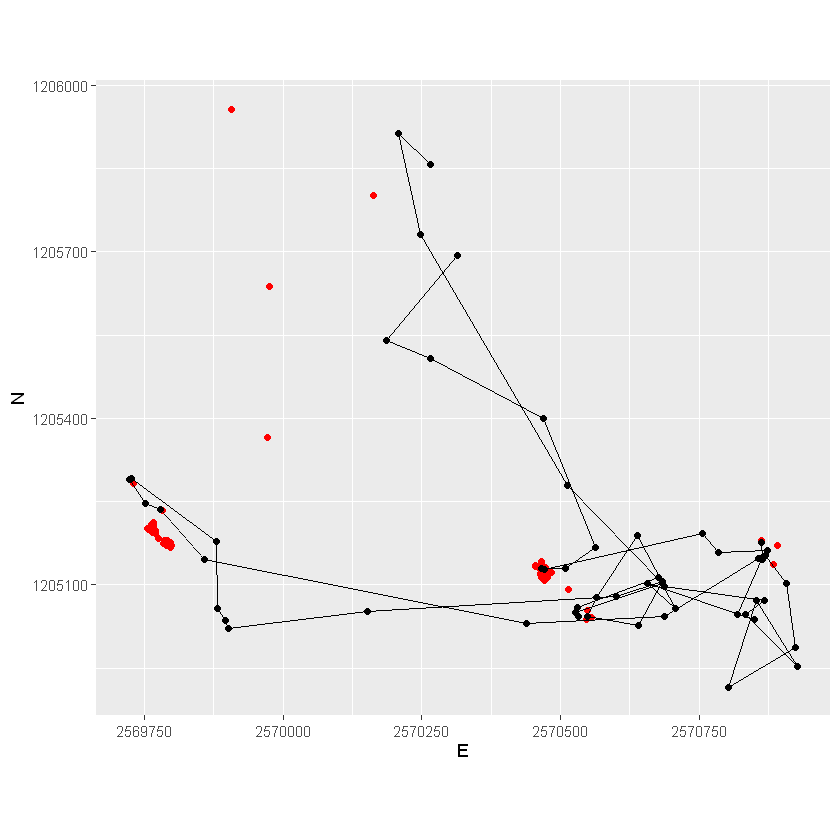

In [24]:
sabi_filter %>%
    ggplot(aes(E, N)) +
    geom_point(data = sabi, col = "red") +
    geom_path() +
    geom_point() +
    coord_fixed() +
    theme(legend.position = "bottom")

# Exercise A: Segmentation
With the skills from *Input Segmentation* you can now implement the segmentation algorithm described in Laube and Purves (2011) to either your own movement data or to a different wild boar using different sampling intervals.

- wildboar **Rosa**
- sampling interval **90 min**

In [25]:
wildschwein <- read_delim("Data/wildschwein_BE_2056.csv", ",")
unique(wildschwein$TierName)

Rows: 51246 Columns: 6
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): TierID, TierName
dbl  (3): CollarID, E, N
dttm (1): DatetimeUTC

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "Sabi" "Rosa" "Ruth"

In [26]:
rosa <- wildschwein %>%
    st_as_sf(coords = c("E", "N"), crs = 2056, remove = FALSE) %>%
    filter(
      TierName == "Rosa", 
      DatetimeUTC >= "2015-06-25", DatetimeUTC < "2015-06-29")

In [27]:
head(rosa)

TierID,TierName,CollarID,DatetimeUTC,E,N,geometry
<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<POINT [m]>
016A,Rosa,13972,2015-06-24 22:00:25,2572667,1203799,POINT (2572667 1203799)
016A,Rosa,13972,2015-06-24 22:15:16,2572615,1203862,POINT (2572615 1203862)
016A,Rosa,13972,2015-06-24 22:30:13,2572610,1203864,POINT (2572610 1203864)
016A,Rosa,13972,2015-06-24 22:45:22,2572547,1203792,POINT (2572547 1203792)
016A,Rosa,13972,2015-06-24 23:01:01,2572548,1203790,POINT (2572548 1203790)
016A,Rosa,13972,2015-06-24 23:15:08,2572550,1203786,POINT (2572550 1203786)


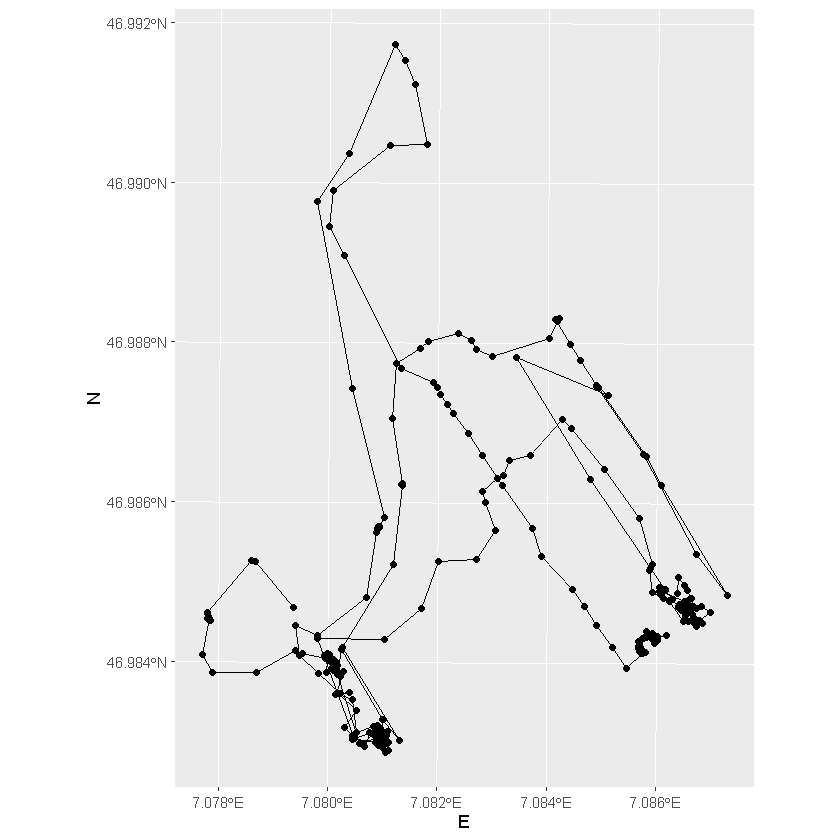

In [28]:
# Hier abgekürzt: ohne zuerst die Linie zu berechnen!

ggplot(rosa) +
    geom_sf() +
    geom_path(aes(E, N)) # geom_path verbindet die Punkte entlang der Reihenfolge im Pfad

## Task 1: Calculate distances
Now, you can 
- Step a): Specify a temporal window v --> **90 min = 6 fixes**
- Step b): Measure the distance to every point within v, which you had used with sabi, on on your own movement data or to a different wild boar using different sampling intervals.

- `pos[n-3]` to `pos[n]`
- `pos[n-2]` to `pos[n]`
- `pos[n-1]` to `pos[n]`
- `pos[n]` to `pos[n+1]`
- `pos[n]` to `pos[n+2]`
- `pos[n]` to `pos[n+3]`

In [29]:
distance_by_element <- function(later, now) {
  as.numeric(
    st_distance(later, now, by_element = TRUE)
  )
}

In [30]:
rosa = rosa %>% mutate(
    nMinus3 = distance_by_element(lag(geometry, n = 3), geometry), # hier lag
    nMinus2 = distance_by_element(lag(geometry, n = 2), geometry),
    nMinus1 = distance_by_element(lag(geometry, n = 1), geometry),
    nPlus1 = distance_by_element(lead(geometry, n = 1), geometry), # hier lead
    nPlus2 = distance_by_element(lead(geometry, n = 2), geometry),
    nPlus3 = distance_by_element(lead(geometry, n = 3), geometry)) %>%
    select(!c(TierID, CollarID, TierName))

In [31]:
head(rosa)
tail(rosa)

DatetimeUTC,E,N,geometry,nMinus3,nMinus2,nMinus1,nPlus1,nPlus2,nPlus3
<dttm>,<dbl>,<dbl>,<POINT [m]>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2015-06-24 22:00:25,2572667,1203799,POINT (2572667 1203799),NA,NA,NA,82.528974,87.148389,120.175026
2015-06-24 22:15:16,2572615,1203862,POINT (2572615 1203862),NA,NA,82.528974,5.280891,97.361665,98.444219
2015-06-24 22:30:13,2572610,1203864,POINT (2572610 1203864),NA,87.148389,5.280891,95.399885,96.549488,98.779814
2015-06-24 22:45:22,2572547,1203792,POINT (2572547 1203792),120.17503,97.361665,95.399885,1.730350,6.396389,11.536301
2015-06-24 23:01:01,2572548,1203790,POINT (2572548 1203790),98.44422,96.549488,1.730350,4.709151,9.882481,8.981012
2015-06-24 23:15:08,2572550,1203786,POINT (2572550 1203786),98.77981,6.396389,4.709151,5.190551,4.333600,2.992715


DatetimeUTC,E,N,geometry,nMinus3,nMinus2,nMinus1,nPlus1,nPlus2,nPlus3
<dttm>,<dbl>,<dbl>,<POINT [m]>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2015-06-28 20:30:12,2573168,1203758,POINT (2573168 1203758),1.111641,2.0477075,2.8455893,0.0000000,1.2576536,1.119242
2015-06-28 20:45:07,2573168,1203758,POINT (2573168 1203758),2.047708,2.8455893,0.0000000,1.2576536,1.1192425,1.418765
2015-06-28 21:00:14,2573167,1203759,POINT (2573167 1203759),2.900353,1.2576536,1.2576536,0.7327951,0.2555874,8.292290
2015-06-28 21:15:08,2573167,1203758,POINT (2573167 1203758),1.119242,1.1192425,0.7327951,0.6561836,8.3197415,NA
2015-06-28 21:30:12,2573167,1203759,POINT (2573167 1203759),1.418765,0.2555874,0.6561836,8.0652006,NA,NA
2015-06-28 21:45:08,2573159,1203760,POINT (2573159 1203760),8.292290,8.3197415,8.0652006,NA,NA,NA


## Task 2: Specify and apply threshold `d`
After calculating the Euclidean distances to positions within the temporal window v in task 1, you can explore these values (we stored them in the column `stepMean`) using summary statistics (histograms, boxplot, summary()): This way we can define a reasonable threshold value to differentiate between stops and moves. There is no “correct” way of doing this, specifying a threshold always depends on data as well as the question that needs to be answered. **In this exercise, use the mean of all stepMean values.**

Store the new information (boolean to differentiate between stops (TRUE) and moves (FALSE)) in a new column named `static`.

In [32]:
rosa = rosa %>% 
    rowwise () %>% # sonst kommt überall NA
    mutate(
    stepMean = mean(c(nMinus3, nMinus2, nMinus1, nPlus1, nPlus2, nPlus3), na.rm = FALSE)) %>% 
    ungroup()  # mit rowwise(() müssen wir wieder ungroupen!
head(rosa)

DatetimeUTC,E,N,geometry,nMinus3,nMinus2,nMinus1,nPlus1,nPlus2,nPlus3,stepMean
<dttm>,<dbl>,<dbl>,<POINT [m]>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2015-06-24 22:00:25,2572667,1203799,POINT (2572667 1203799),NA,NA,NA,82.528974,87.148389,120.175026,NA
2015-06-24 22:15:16,2572615,1203862,POINT (2572615 1203862),NA,NA,82.528974,5.280891,97.361665,98.444219,NA
2015-06-24 22:30:13,2572610,1203864,POINT (2572610 1203864),NA,87.148389,5.280891,95.399885,96.549488,98.779814,NA
2015-06-24 22:45:22,2572547,1203792,POINT (2572547 1203792),120.17503,97.361665,95.399885,1.730350,6.396389,11.536301,55.43327
2015-06-24 23:01:01,2572548,1203790,POINT (2572548 1203790),98.44422,96.549488,1.730350,4.709151,9.882481,8.981012,36.71612
2015-06-24 23:15:08,2572550,1203786,POINT (2572550 1203786),98.77981,6.396389,4.709151,5.190551,4.333600,2.992715,20.40037


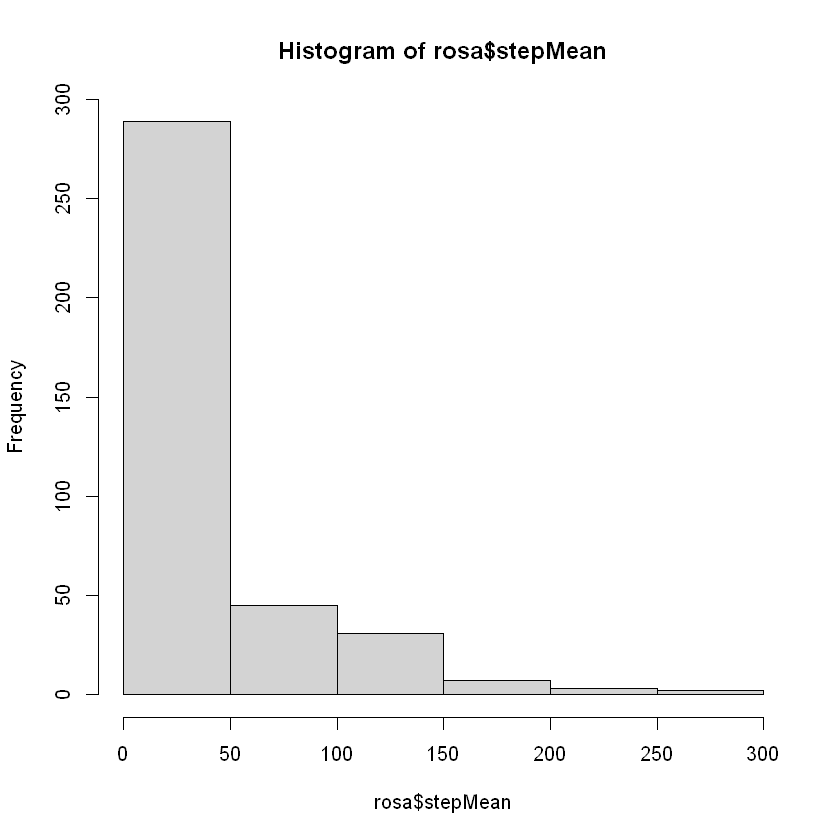

In [33]:
hist(rosa$stepMean)

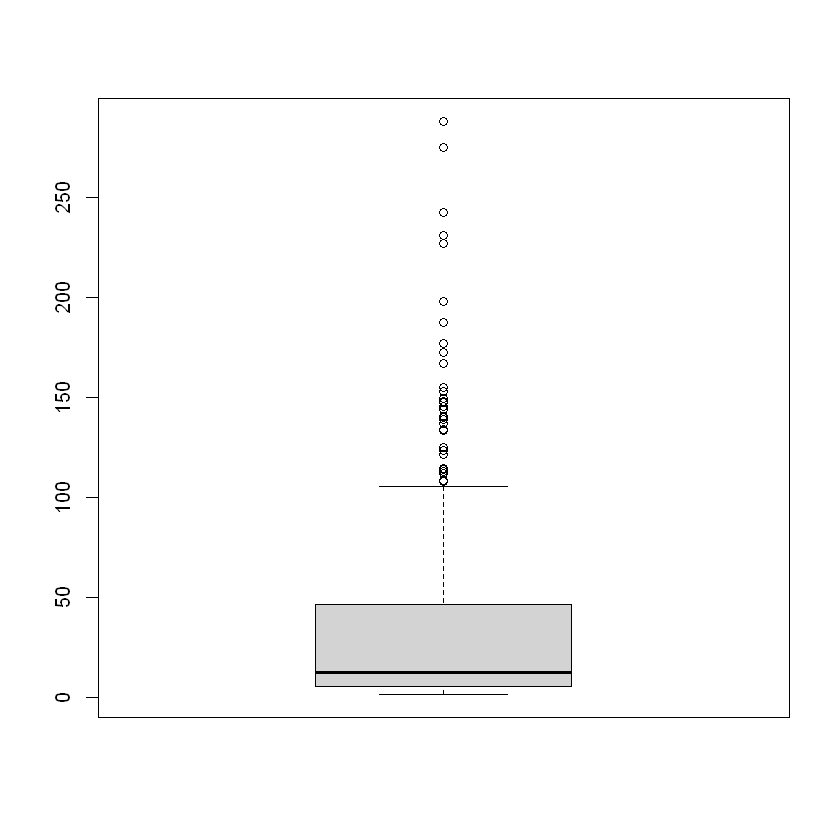

In [34]:
boxplot(rosa$stepMean)

In [35]:
summary(rosa$stepMean)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  1.199   5.442  12.532  34.764  46.268 288.194       6 

In [36]:
treshold = mean(rosa$stepMean, na.rm = TRUE)
treshold

[1] 34.76389

In [37]:
rosa <- rosa %>%
    mutate(static = stepMean < treshold)
head(rosa)

DatetimeUTC,E,N,geometry,nMinus3,nMinus2,nMinus1,nPlus1,nPlus2,nPlus3,stepMean,static
<dttm>,<dbl>,<dbl>,<POINT [m]>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
2015-06-24 22:00:25,2572667,1203799,POINT (2572667 1203799),NA,NA,NA,82.528974,87.148389,120.175026,NA,NA
2015-06-24 22:15:16,2572615,1203862,POINT (2572615 1203862),NA,NA,82.528974,5.280891,97.361665,98.444219,NA,NA
2015-06-24 22:30:13,2572610,1203864,POINT (2572610 1203864),NA,87.148389,5.280891,95.399885,96.549488,98.779814,NA,NA
2015-06-24 22:45:22,2572547,1203792,POINT (2572547 1203792),120.17503,97.361665,95.399885,1.730350,6.396389,11.536301,55.43327,FALSE
2015-06-24 23:01:01,2572548,1203790,POINT (2572548 1203790),98.44422,96.549488,1.730350,4.709151,9.882481,8.981012,36.71612,FALSE
2015-06-24 23:15:08,2572550,1203786,POINT (2572550 1203786),98.77981,6.396389,4.709151,5.190551,4.333600,2.992715,20.40037,TRUE


## Task 3: Visualize segmented trajectories
Now visualize the segmented trajectory spatially. Just like last week, you can use `ggplot` with `geom_path()`, `geom_point()` and `coord_equal()`. Assign **colour = static** within aes() to distinguish between segments with “movement” and without.

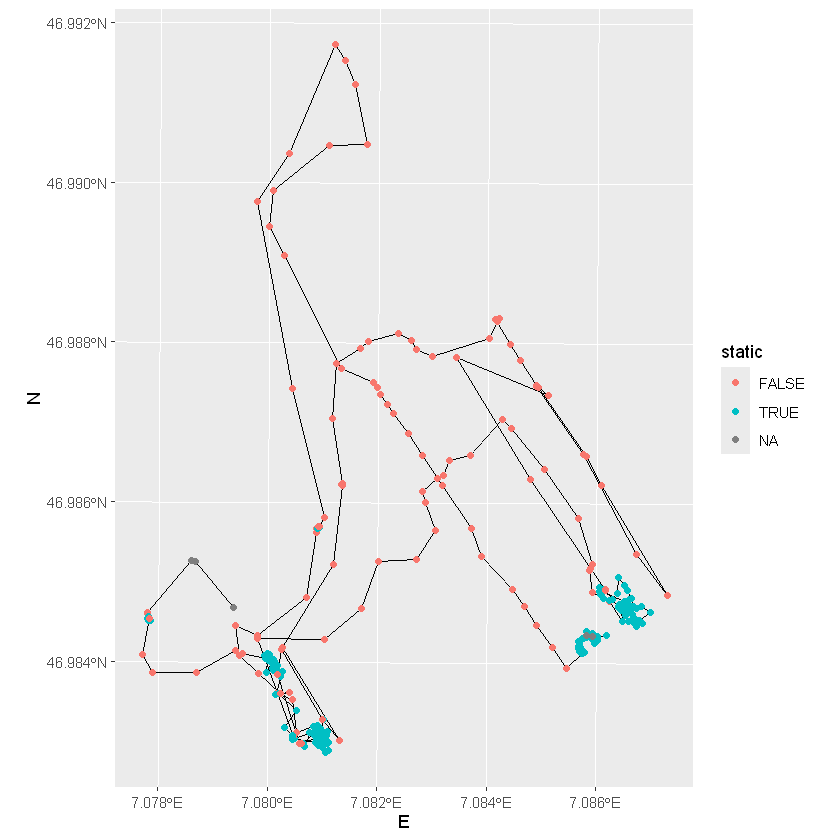

In [38]:
ggplot(rosa) +
    geom_path(aes(E, N)) +
    geom_sf(aes(color = static)) 

In [39]:
rosa_filter <- rosa %>%
    filter(!static)

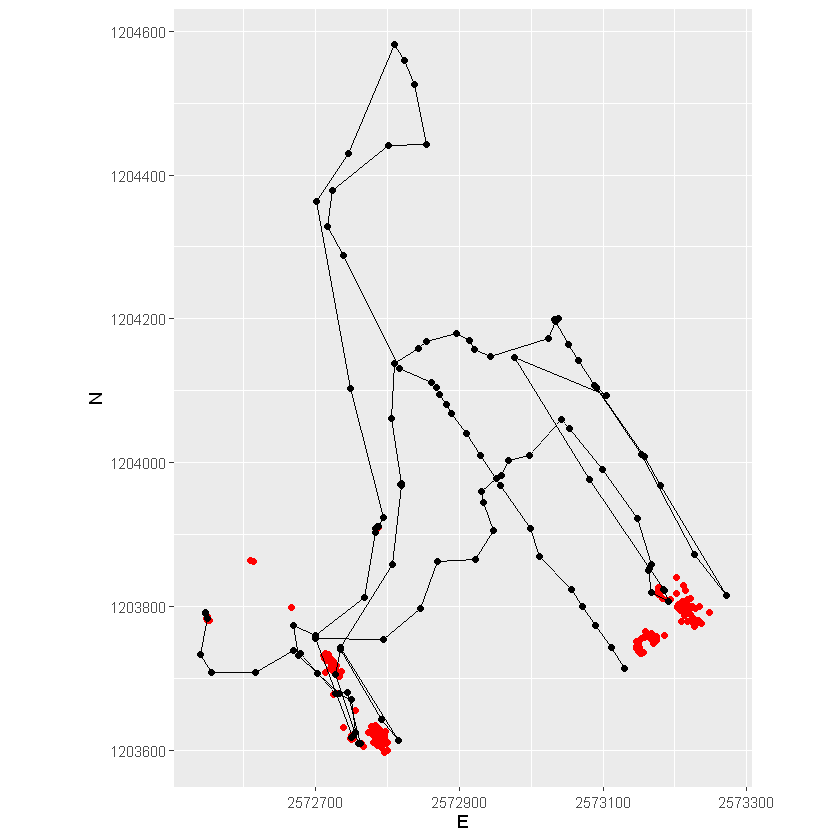

In [40]:
rosa_filter %>%
    ggplot(aes(E, N)) +
    geom_point(data = rosa, col = "red") +
    geom_path() +
    geom_point() +
    coord_fixed() +
    theme(legend.position = "bottom")

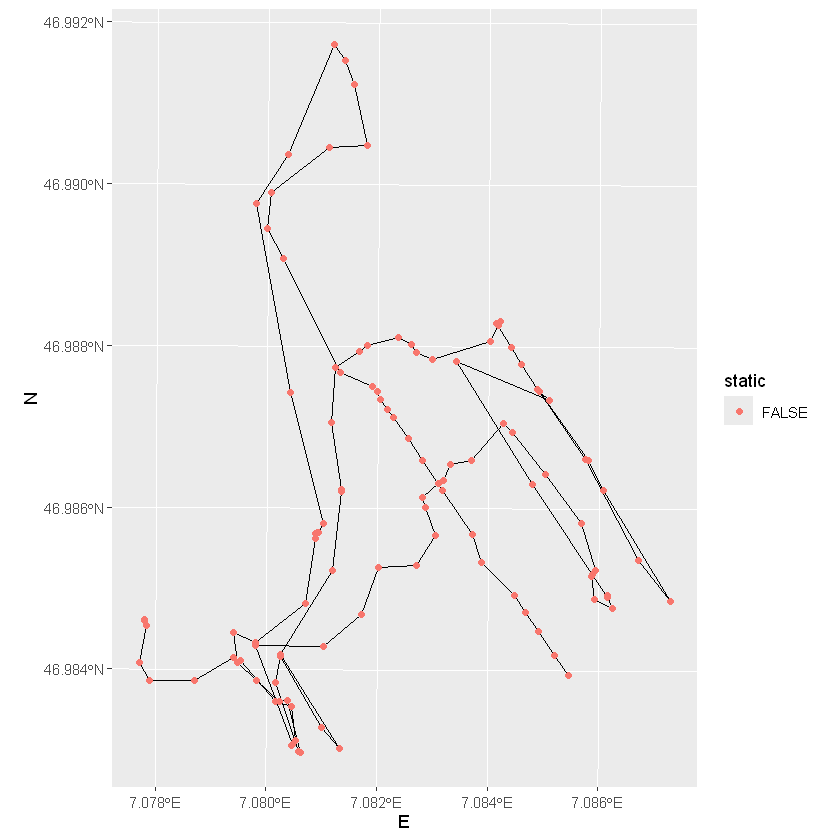

In [41]:
ggplot(rosa_filter) +
    geom_path(aes(E, N)) +
    geom_sf(aes(color = static)) 

## Task 4: Segment-based analysis
In applying Laube and Purves (2011), we’ve come as far as step b) in Figure 16.1. In order to complete the last steps (c and d), we need a **unique ID for each segment** that we can use as a ***grouping variable***. The following function does just that (it assigns unique IDs based on the column static which you created in Task 2). You will learn about functions next week. For now, just copy the following code chunk into your script and run it.

In [42]:
rle_id <- function(vec) {
    x <- rle(vec)$lengths
    as.factor(rep(seq_along(x), times = x))
}

You can use the newly created function `rle_id` to assign unique IDs to subtrajectories (as shown below). Visualize the moving segments by **colourizing them by segment_ID**. Then use segment_ID as a grouping variable to determine the segments duration and remove short segments (e.g. segments with a duration < 5 Minutes)

### Apply function

In [43]:
rosa <- rosa %>%
    mutate(segment_id = rle_id(static))

In [44]:
rosa[1:10, ]

DatetimeUTC,E,N,geometry,nMinus3,nMinus2,nMinus1,nPlus1,nPlus2,nPlus3,stepMean,static,segment_id
<dttm>,<dbl>,<dbl>,<POINT [m]>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<fct>
2015-06-24 22:00:25,2572667,1203799,POINT (2572667 1203799),NA,NA,NA,82.528974,87.148389,120.1750262,NA,NA,1
2015-06-24 22:15:16,2572615,1203862,POINT (2572615 1203862),NA,NA,82.528974,5.280891,97.361665,98.4442193,NA,NA,2
2015-06-24 22:30:13,2572610,1203864,POINT (2572610 1203864),NA,87.148389,5.280891,95.399885,96.549488,98.7798139,NA,NA,3
2015-06-24 22:45:22,2572547,1203792,POINT (2572547 1203792),120.175026,97.361665,95.399885,1.730350,6.396389,11.5363008,55.433269,FALSE,4
2015-06-24 23:01:01,2572548,1203790,POINT (2572548 1203790),98.444219,96.549488,1.730350,4.709151,9.882481,8.9810122,36.716117,FALSE,4
2015-06-24 23:15:08,2572550,1203786,POINT (2572550 1203786),98.779814,6.396389,4.709151,5.190551,4.333600,2.9927145,20.400370,TRUE,5
2015-06-24 23:30:13,2572552,1203781,POINT (2572552 1203781),11.536301,9.882481,5.190551,1.869585,4.229091,2.3024597,5.835078,TRUE,5
2015-06-24 23:45:07,2572550,1203781,POINT (2572550 1203781),8.981012,4.333600,1.869585,2.516089,1.406039,1.2516307,3.392993,TRUE,5
2015-06-25 00:00:12,2572548,1203783,POINT (2572548 1203783),2.992715,4.229091,2.516089,3.486170,3.767719,3.2293705,3.370192,TRUE,5


In [45]:
# Immer wenn sich der Wert in der Spalte "static" ändert, wird eine neue "segment_id" zugewiesen

In [46]:
unique(rosa$segment_id)

[1] 1  2  3  4  5  6  7  8  9  10 11 12 13 14 15 16 17 18 19 20
Levels: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20

### Visualize moving segments

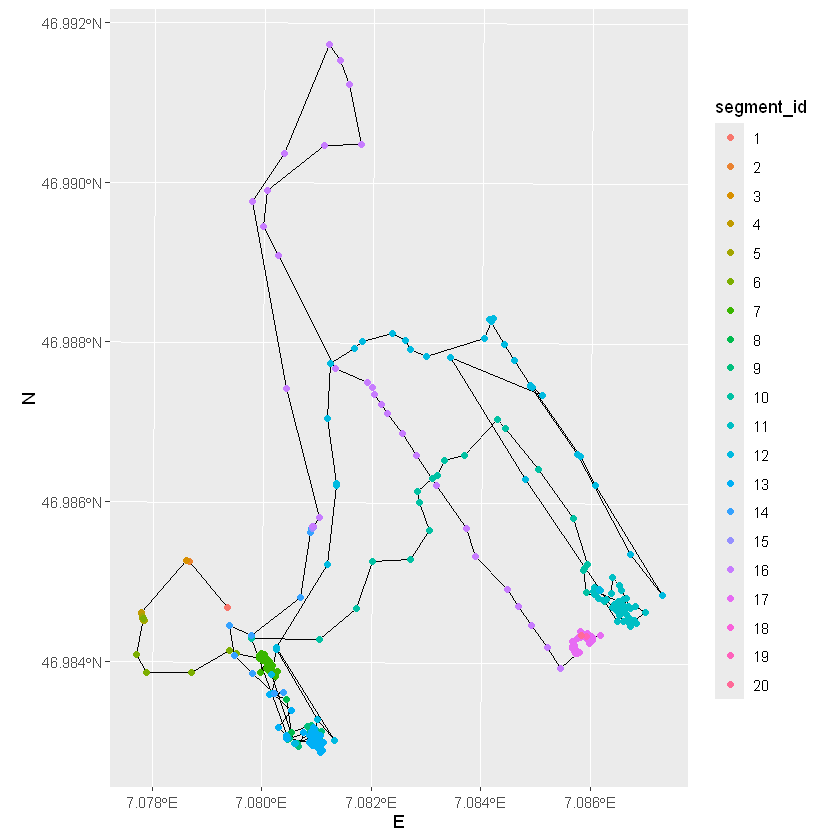

In [47]:
ggplot(rosa) +
    geom_path(aes(E, N)) +
    geom_sf(aes(color = segment_id))

### Detemine segment duration
Use segment_ID as a grouping variable to determine the segments duration and remove short segments (e.g. segments with a duration < 5 Minutes)

--> ich will mindestens 4 Zeitschritte (4x15min = 1h)

In [48]:
rosa_grouped <- rosa %>%
    group_by(segment_id) %>%
    summarise(segm_length = length(segment_id)) 

rosa_grouped

segment_id,segm_length,geometry
<fct>,<int>,<GEOMETRY [m]>
1,1,POINT (2572667 1203799)
2,1,POINT (2572615 1203862)
3,1,POINT (2572610 1203864)
4,2,MULTIPOINT ((2572547 120379...
5,8,MULTIPOINT ((2572548 120378...
6,6,MULTIPOINT ((2572541 120373...
7,32,MULTIPOINT ((2572711 120373...
8,3,MULTIPOINT ((2572728 120367...
9,33,MULTIPOINT ((2572750 120361...


In [49]:
which(rosa_grouped$segm_length < 4)

[1]  1  2  3  4  8 15 18 19 20

In [50]:
drop_segm <- which(rosa_grouped$segm_length < 4)
drop_segm

[1]  1  2  3  4  8 15 18 19 20

In [51]:
rosa_clean <- rosa %>% 
  filter(!segment_id %in% drop_segm)

head(rosa_clean)  
unique(rosa_clean$segment_id)

DatetimeUTC,E,N,geometry,nMinus3,nMinus2,nMinus1,nPlus1,nPlus2,nPlus3,stepMean,static,segment_id
<dttm>,<dbl>,<dbl>,<POINT [m]>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<fct>
2015-06-24 23:15:08,2572550,1203786,POINT (2572550 1203786),98.779814,6.396389,4.709151,5.1905508,4.333600,2.9927145,20.400370,TRUE,5
2015-06-24 23:30:13,2572552,1203781,POINT (2572552 1203781),11.536301,9.882481,5.190551,1.8695852,4.229091,2.3024597,5.835078,TRUE,5
2015-06-24 23:45:07,2572550,1203781,POINT (2572550 1203781),8.981012,4.333600,1.869585,2.5160894,1.406039,1.2516307,3.392993,TRUE,5
2015-06-25 00:00:12,2572548,1203783,POINT (2572548 1203783),2.992715,4.229091,2.516089,3.4861704,3.767719,3.2293705,3.370192,TRUE,5
2015-06-25 00:15:38,2572550,1203780,POINT (2572550 1203780),2.302460,1.406039,3.486170,1.2787909,1.499217,0.9930123,1.827615,TRUE,5
2015-06-25 00:30:12,2572551,1203781,POINT (2572551 1203781),1.251631,3.767719,1.278791,0.6375228,0.732795,2.9858424,1.775717,TRUE,5


[1] 5  6  7  9  10 11 12 13 14 16 17
Levels: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20

### Visualize cleaned segments

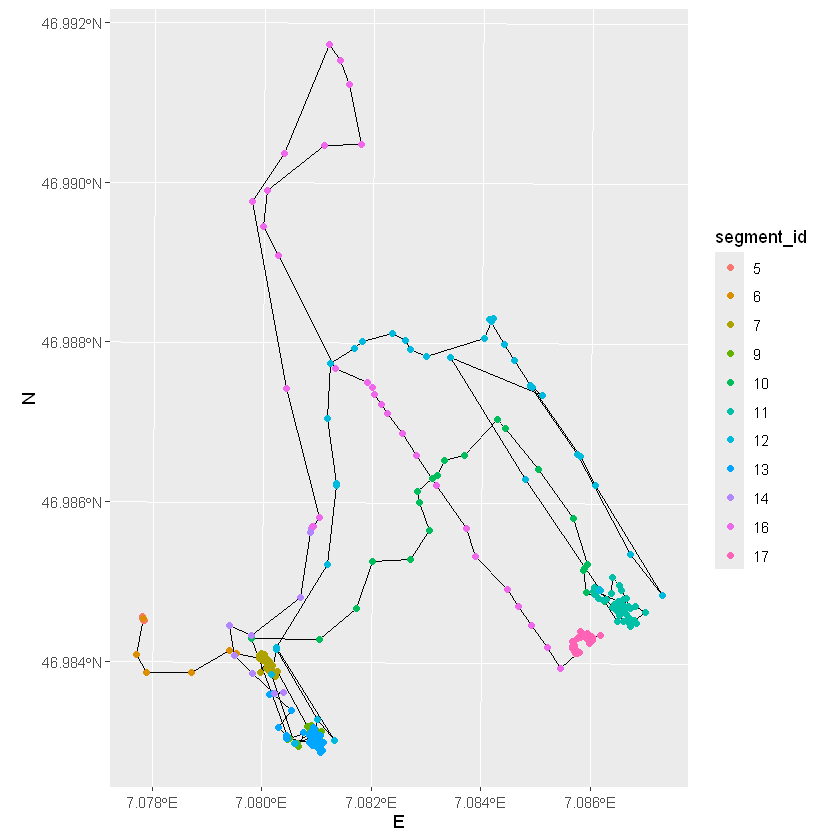

In [52]:
ggplot(rosa_clean) +
    geom_path(aes(E, N)) +
    geom_sf(aes(color = segment_id)) 

# Exercise B: Similarity

## Task 1: Similarity measures
We will now **calculate similarities between trajectories** using a new dataset `pedestrian.csv` (available on moodle). Download an import this dataset as a data.frame or tibble. It it a set of 6 different but similar trajectories from pedestrians walking on a path.

For this task, explore the trajectories first and get an idea on how the pedestrians moved.

In [53]:
pedestrian <- read_delim("Data/pedestrian.csv", ",")

# Careful! What Timezone is assumed?
pedestrian <- pedestrian %>%
    st_as_sf(coords = c("E", "N"), crs = 2056, remove = FALSE) 
head(pedestrian)

Rows: 289 Columns: 4
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
dbl  (3): TrajID, E, N
dttm (1): DatetimeUTC

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


TrajID,E,N,DatetimeUTC,geometry
<dbl>,<dbl>,<dbl>,<dttm>,<POINT [m]>
1,2571414,1205804,2015-03-01 12:01:00,POINT (2571414 1205804)
1,2571396,1205791,2015-03-01 12:02:00,POINT (2571396 1205791)
1,2571373,1205770,2015-03-01 12:03:00,POINT (2571373 1205770)
1,2571347,1205753,2015-03-01 12:04:00,POINT (2571347 1205753)
1,2571336,1205744,2015-03-01 12:05:00,POINT (2571336 1205744)
1,2571321,1205732,2015-03-01 12:06:00,POINT (2571321 1205732)


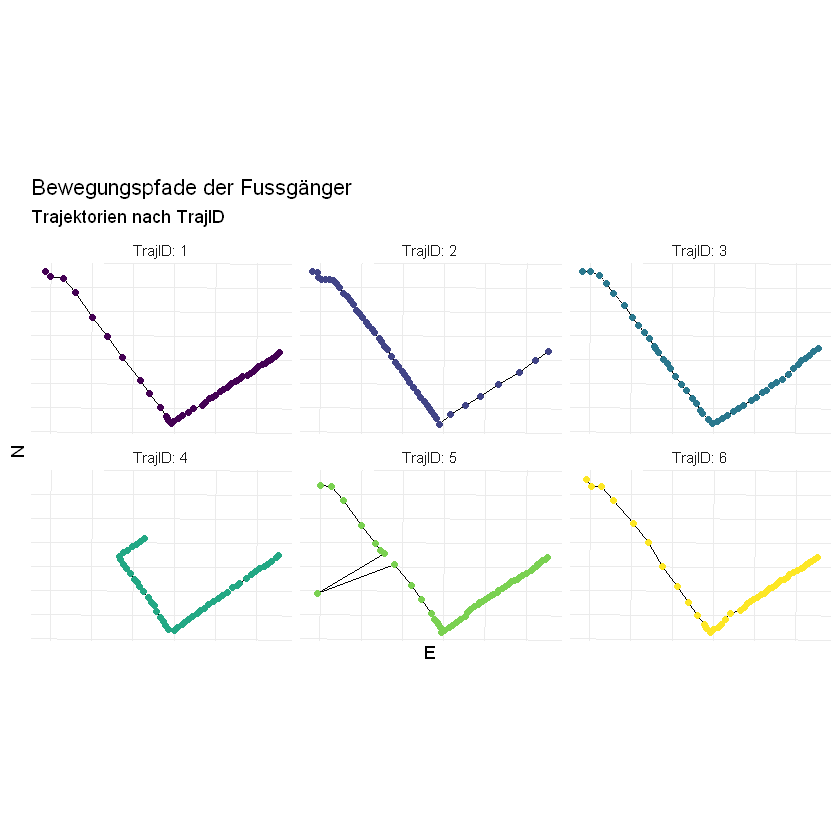

In [54]:
ggplot(pedestrian) +
  geom_path(aes(E, N)) +
  geom_sf(aes(color = TrajID), show.legend = FALSE) +   # verhindert zusätzliche Legenden
  facet_wrap(~TrajID,
             labeller = labeller(TrajID = function(x) paste("TrajID:", x))) +
  labs(
    title = "Bewegungspfade der Fussgänger",
    subtitle = "Trajektorien nach TrajID",
    x = "E",                      # lassen die Achsentitel stehen
    y = "N"
  ) +
  theme_minimal() +
  theme(
    axis.text = element_blank(),  # entfernt Zahlen auf den Achsen
    axis.ticks = element_blank(),
    legend.position = "none"      # entfernt die Farblegende
  ) +
  scale_color_viridis_c()

In [55]:
pedestrian_test <- pedestrian %>%
    filter(TrajID == 3)
head(pedestrian_test)

TrajID,E,N,DatetimeUTC,geometry
<dbl>,<dbl>,<dbl>,<dttm>,<POINT [m]>
3,2569231,1206553,2015-03-01 12:01:00,POINT (2569231 1206553)
3,2569307,1206555,2015-03-01 12:02:00,POINT (2569307 1206555)
3,2569388,1206519,2015-03-01 12:03:00,POINT (2569388 1206519)
3,2569456,1206442,2015-03-01 12:04:00,POINT (2569456 1206442)
3,2569518,1206352,2015-03-01 12:05:00,POINT (2569518 1206352)
3,2569625,1206237,2015-03-01 12:06:00,POINT (2569625 1206237)


In [56]:
library(leaflet)

pedestrian_test_wgs <- st_transform(pedestrian_test, 4326) # Leaflet will WGS84... = 4326

leaflet(pedestrian_test_wgs) %>%
  addTiles() %>%
  addCircleMarkers()

Warning message:
"Paket 'leaflet' wurde unter R Version 4.5.3 erstellt"


HTML widgets cannot be represented in plain text (need html)

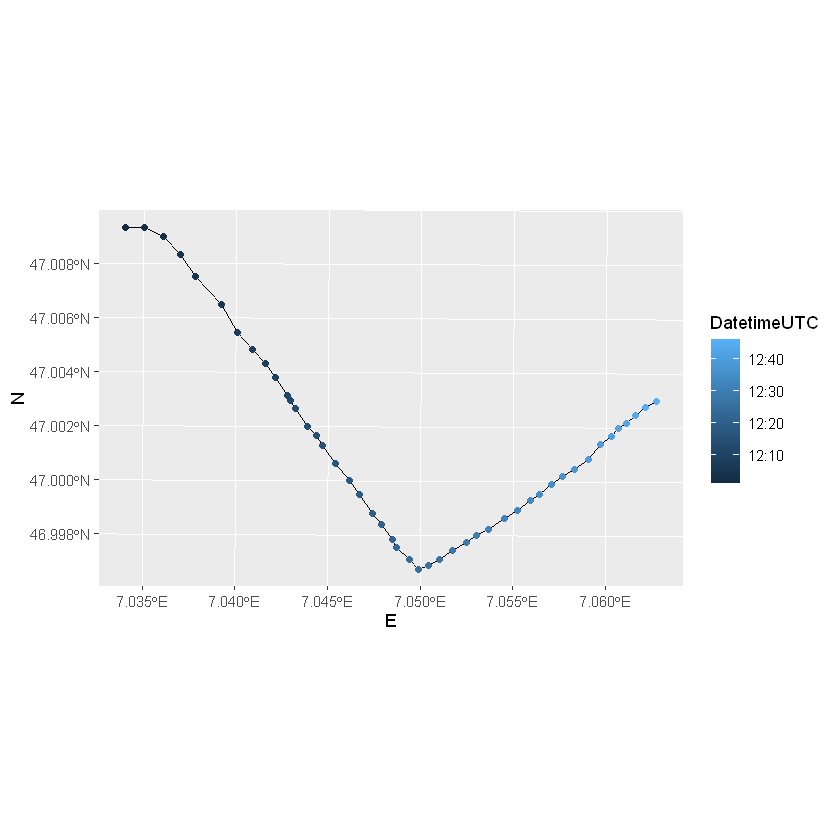

In [57]:
ggplot(pedestrian_test) +
    geom_path(aes(E, N)) +
    geom_sf(aes(color = DatetimeUTC)) 

## Task 2: Calculate similarity
Install the package `SimilarityMeasures` (install.packages("SimilarityMeasures")). Familiarize yourself with this package by skimming through the function descriptions help(package = "SimilarityMeasures"). Now **compare trajectory 1 to trajectories 2-6 using different similarity measures from the package**. Your options are. `DTW, EditDist, Frechet and LCSS`.

Before visualizing your results think about the following: Which two trajectories to you perceive to be most similar, which are most dissimilar? Now visualize the results from the computed similarity measures. Which measure reflects your own intuition the closest?

- most similar: 2 & 3
- most dissimilar: 4 & 5

Note:
- **All functions in the package need matrices as input, with one trajectory per matrix.**
- `LCSS` takes very long to compute. The accuracy of the algorithm (`pointSpacing = `, `pointDistance =` and `errorMarg =`) can be varied to provide faster calculations. Please see Vlachos et al. (2002) for more information.

In [58]:
help(package = "SimilarityMeasures")

Dokumentation für Paket 'SimilarityMeasures'


		Information für Paket 'SimilarityMeasures'

Description:

Package:            SimilarityMeasures
Type:               Package
Title:              Trajectory Similarity Measures
Version:            1.4
Date:               2015-02-06
Author:             Kevin Toohey
Maintainer:         Kevin Toohey <kevintoohey@live.com>
Description:        Functions to run and assist four different
                    similarity measures. The similarity measures
                    included are: longest common subsequence (LCSS),
                    Frechet distance, edit distance and dynamic time
                    warping (DTW). Each of these similarity measures
                    can be calculated from two n-dimensional
                    trajectories, both in matrix form.
License:            GPL-3
NeedsCompilation:   no
Packaged:           2015-02-06 02:29:48 UTC; Awesome
Repository:         CRAN
Date/Publication:   2015-02-06 06:19:21
Built:       

### Funktion schreiben & Matrix erstellen

Die Funktionen aus der Library `SimilarityMeasures` fordern für jede Trajektorie eine **Matrix** bestehend aus 2 Spalten: den Koordinaten (hier E und N). Dazu müssen die Daten entsprechend aufbereitet/transformiert werden:

 1. Filtern nach TrajID
 2. Nach Zeitstempel sortieren (zur Sicherheit...)
 3. Geometrie droppen
 4. Koordinaten auswählen
 5. als Matrix wiedergeben

Dazu schreibe ich am besten eine Funktion:

In [59]:
traj_matrix <- function(data, id) {
  data %>%
    filter(TrajID == id) %>%
    arrange(DatetimeUTC) %>%
    st_drop_geometry() %>%
    select(E, N) %>%
    as.matrix()
}

In [60]:
library(SimilarityMeasures)

traj1 <- traj_matrix(pedestrian, 1)
traj2 <- traj_matrix(pedestrian, 2)
traj3 <- traj_matrix(pedestrian, 3)
traj4 <- traj_matrix(pedestrian, 4)
traj5 <- traj_matrix(pedestrian, 5)
traj6 <- traj_matrix(pedestrian, 6)

Warning message:
"Paket 'SimilarityMeasures' wurde unter R Version 4.5.2 erstellt"


In [61]:
head(traj1)
head(traj2)

E,N
2571414,1205804
2571396,1205791
2571373,1205770
2571347,1205753
2571336,1205744
2571321,1205732


E,N
2571408,1205818
2571282,1205730
2571136,1205624
2570947,1205514
2570784,1205401
2570640,1205315


### DTW

The dynamic time warping algorithm (DTW) calculates the smallest warp path for the two trajectories. This is the DTW version discussed by Berndt & Clifford (1994). Several variations of calculating the warping cost exist. In this version, the warping path is equal to the sum of the distances at each point along the path. Please see the references for more information.

**Output**: A floating point value representing the smallest warp path is returned. If a problem occurs, then a string containing information about the problem is returned.

In [114]:
val = 5

dtw2 <- DTW(traj1, traj2, pointSpacing = val)
dtw3 <- DTW(traj1, traj3, pointSpacing = val)
dtw4 <- DTW(traj1, traj4, pointSpacing = val)
dtw5 <- DTW(traj1, traj5, pointSpacing = val)
dtw6 <- DTW(traj1, traj6, pointSpacing = val)

dtw_all <- data.frame(
  Traj = as.character(c(2:6)),
  DTW = c(dtw2, dtw3, dtw4, dtw5, dtw6)
)

dtw_all

Traj,DTW
<chr>,<dbl>
2,28135.752
3,50785.511
4,8229.858
5,2868.852
6,1152.718


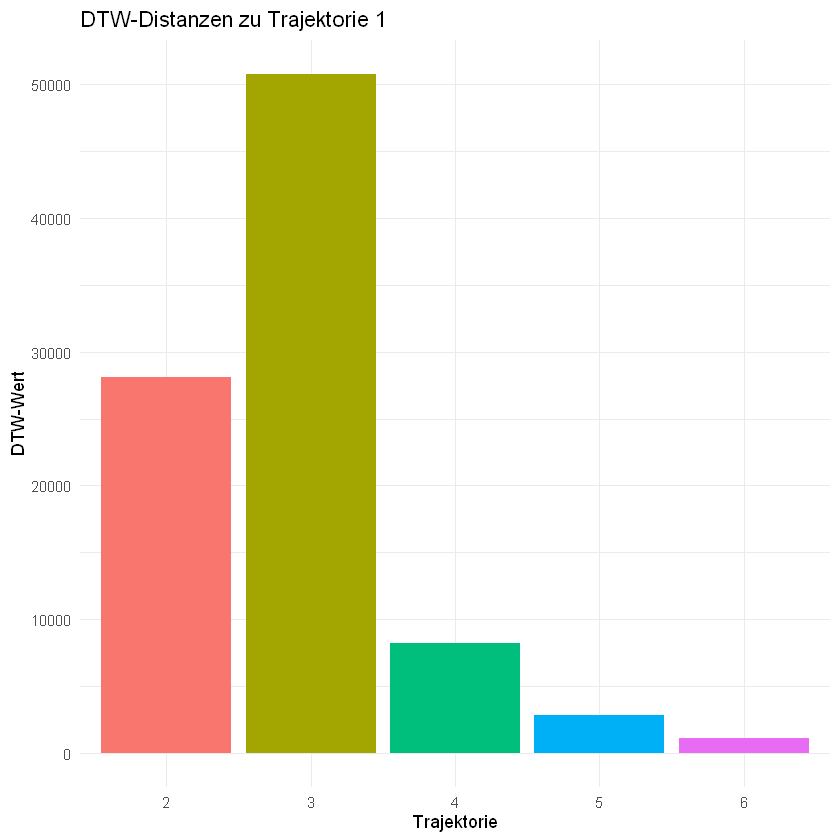

In [66]:
ggplot(dtw_all, aes(x = DTW, y = Value, fill = DTW)) + 
  geom_col(show.legend = FALSE) +
  labs(
    title = "DTW-Distanzen zu Trajektorie 1",
    x = "Trajektorie",
    y = "DTW-Wert"
  ) +
  theme_minimal()

### EditDist

The edit distance algorithm calculates the minimum number of edits required to allow the two trajectories to be considered equivalent. This function uses Edit Distance on Real sequence (EDR) as described by Chen et al. (2005). Please see the references for more information.

**Output**: An integer representing the minimum number of edits required is returned. If a problem occurs, then a string containing information about the problem is returned.

In [115]:
val = 1

editdist2 <- EditDist(traj1, traj2, pointDistance = val)
editdist3 <- EditDist(traj1, traj3, pointDistance = val)
editdist4 <- EditDist(traj1, traj4, pointDistance = val)
editdist5 <- EditDist(traj1, traj5, pointDistance = val)
editdist6 <- EditDist(traj1, traj6, pointDistance = val)

editdist_all <- data.frame(
  Traj = as.character(c(2:6)),
  EditDist = c(editdist2, editdist3, editdist4, editdist5, editdist6)
)

editdist_all

Traj,EditDist
<chr>,<dbl>
2,48
3,47
4,49
5,52
6,47


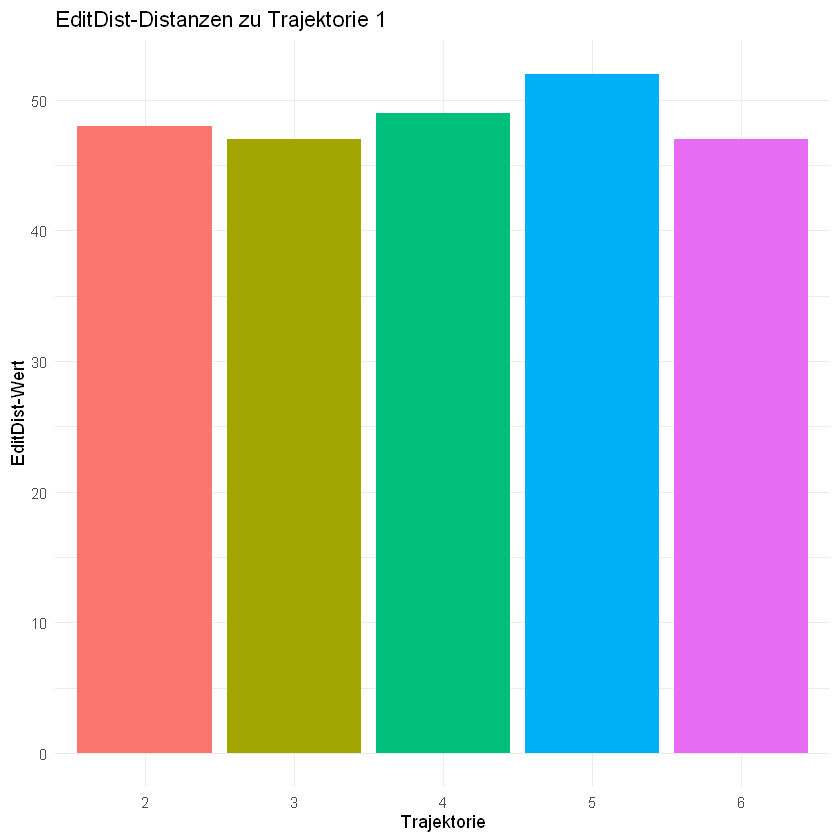

In [75]:
ggplot(editdist_all, aes(x = EditDist, y = Value, fill = EditDist)) + 
  geom_col(show.legend = FALSE) +
  labs(
    title = "EditDist-Distanzen zu Trajektorie 1",
    x = "Trajektorie",
    y = "EditDist-Wert"
  ) +
  theme_minimal()

### Frechet

This algorithm calculates the Frechet distance. The Frechet metric (or distance) is generally described in the following way: A man is walking a dog on a leash, the man walks on one curve while the dog walks on the other (Alt & Godau, 1995). The dog and the man are able to vary their speeds, or even stop, but not go backwards. The Frechet metric is the minimum leash length required to complete the traversal of both curves. Please see the references for more information.

**Output**: A floating point value representing the Frechet distance is returned. If a test leash is given, then a boolean value is returned as true if the leash was successful and false if not. If a problem occurs, then a string containing information about the problem is returned.

In [116]:
frechet2 <- Frechet(traj1, traj2)
frechet3 <- Frechet(traj1, traj3)
frechet4 <- Frechet(traj1, traj4)
frechet5 <- Frechet(traj1, traj5)
frechet6 <- Frechet(traj1, traj6)

frechet_all <- data.frame(
  Traj = as.character(c(2:6)),
  Frechet = c(frechet2, frechet3, frechet4, frechet5, frechet6)
)

frechet_all

Traj,Frechet
<chr>,<dbl>
2,28.54075
3,2307.84366
4,1069.22917
5,717.98159
6,38.96272


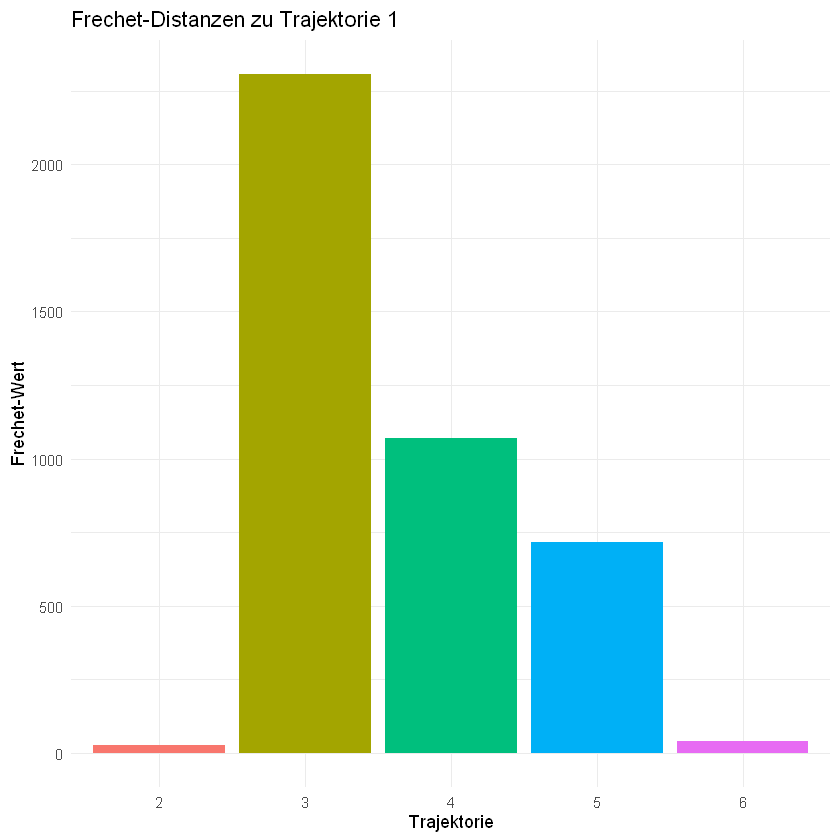

In [93]:
ggplot(frechet_all, aes(x = Frechet, y = Value, fill = Frechet)) + 
  geom_col(show.legend = FALSE) +
  labs(
    title = "Frechet-Distanzen zu Trajektorie 1",
    x = "Trajektorie",
    y = "Frechet-Wert"
  ) +
  theme_minimal()

### LCSS

The LCSS algorithm calculates the largest number of equivalent points between the two trajectories when traversed in a monotone way. Possible translations are calculated in each dimension and used to provide the maximum LCSS. The accuracy of the algorithm can be varied to provide faster or slower calculations. Please see the references for more information.

**Output**: An integer value is returned. This represents the maximum LCSS value obtained using the variables provided. If returnTrans is set to TRUE, then the LCSS value and the translations are returned as a vector. The first value of this vector is the LCSS value and the translations follow directly afterwards. If a problem occurs, then a string containing information about the problem is returned.

**WICHTIG!!**: LCSS takes very long to compute. The accuracy of the algorithm (pointSpacing = , pointDistance = and errorMarg =) can be varied to provide faster calculations. Please see Vlachos et al. (2002) for more information.

In [117]:
PS <- 6
EM <- 3

lcss2 <- LCSS(traj1, traj2, pointSpacing = PS, pointDistance = PS, errorMarg = EM)
lcss3 <- LCSS(traj1, traj3, pointSpacing = PS, pointDistance = PS, errorMarg = EM)
lcss4 <- LCSS(traj1, traj4, pointSpacing = PS, pointDistance = PS, errorMarg = EM)
lcss5 <- LCSS(traj1, traj5, pointSpacing = PS, pointDistance = PS, errorMarg = EM)
lcss6 <- LCSS(traj1, traj6, pointSpacing = PS, pointDistance = PS, errorMarg = EM)

lcss_all <- data.frame(
  Traj = as.character(c(2:6)),
  LCSS = c(lcss2, lcss3, lcss4, lcss5, lcss6)
)

lcss_all

Traj,LCSS
<chr>,<dbl>
2,2
3,1
4,2
5,5
6,8


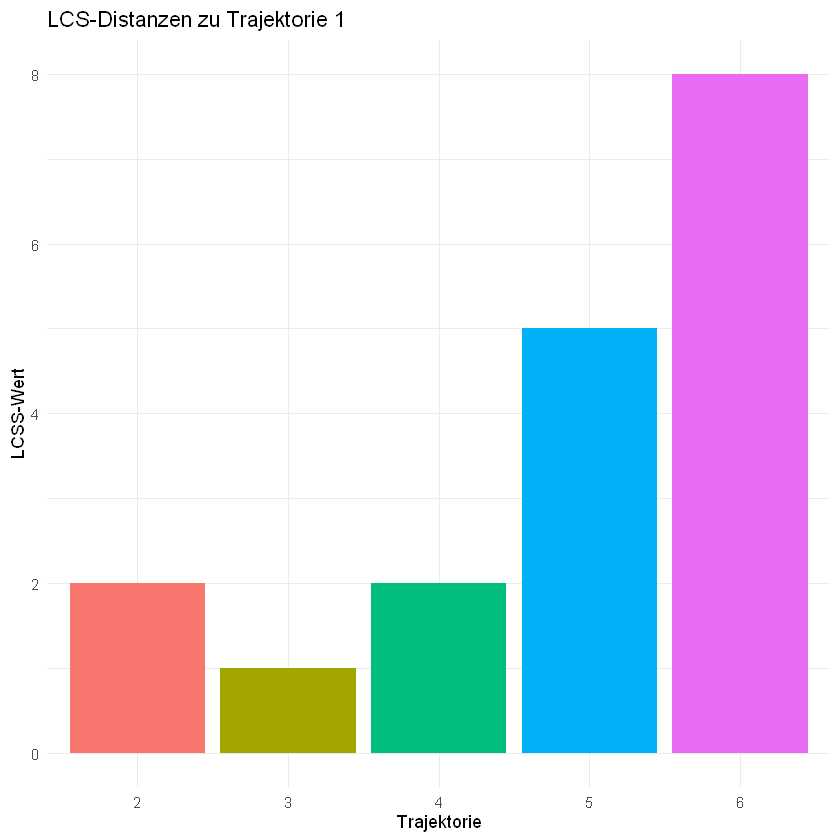

In [113]:
ggplot(lcss_all, aes(x = LCSS, y = Value, fill = LCSS)) + 
  geom_col(show.legend = FALSE) +
  labs(
    title = "LCS-Distanzen zu Trajektorie 1",
    x = "Trajektorie",
    y = "LCSS-Wert"
  ) +
  theme_minimal()

In [120]:
similarity <- cbind(dtw_all$DTW, editdist_all$EditDist, frechet_all$Frechet, lcss_all$LCSS)
similarity

28135.752,48,28.54075,2
50785.511,47,2307.84366,1
8229.858,49,1069.22917,2
2868.852,52,717.98159,5
1152.718,47,38.96272,8


In [123]:
combined <- dtw_all %>%
  left_join(editdist_all, by = "Traj") %>%
  left_join(frechet_all, by = "Traj")  %>%
  left_join(lcss_all, by = "Traj")

combined

Traj,DTW,EditDist,Frechet,LCSS
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
2,28135.752,48,28.54075,2
3,50785.511,47,2307.84366,1
4,8229.858,49,1069.22917,2
5,2868.852,52,717.98159,5
6,1152.718,47,38.96272,8


In [127]:
combined_long <- combined %>%
  pivot_longer(
    cols = -Traj,
    names_to = "Similarity",
    values_to = "Value"
  )

head(combined_long)

Traj,Similarity,Value
<chr>,<chr>,<dbl>
2,DTW,28135.75212
2,EditDist,48.00000
2,Frechet,28.54075
2,LCSS,2.00000
3,DTW,50785.51138
3,EditDist,47.00000


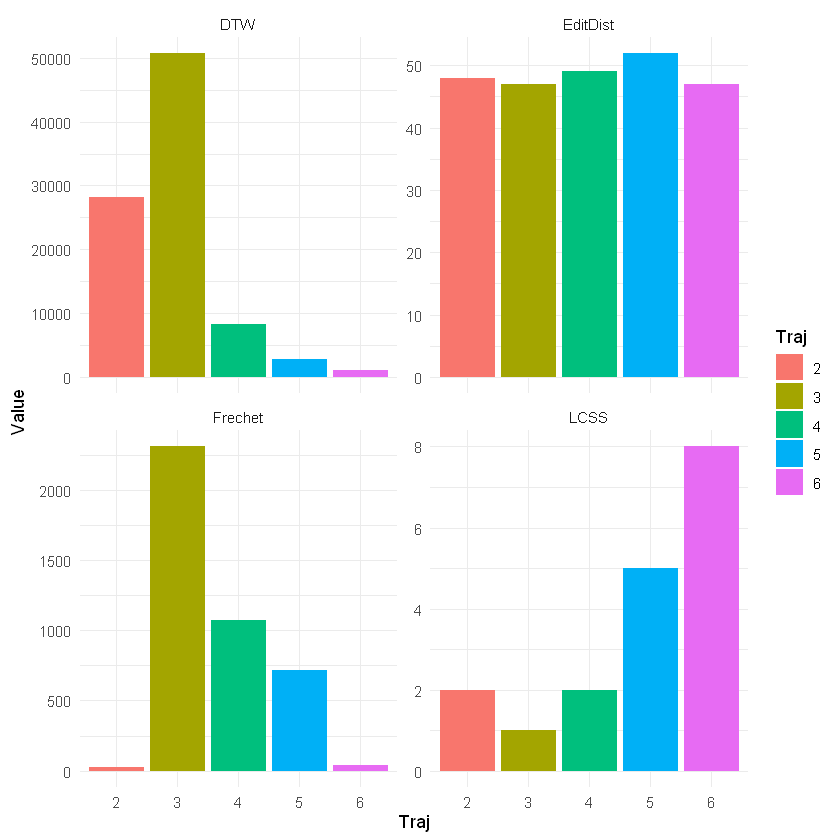

In [131]:
ggplot(combined_long,
       aes(x = Traj, y = Value, fill = Traj)) +
  geom_col(position = "dodge") +
  theme_minimal() +
  facet_wrap(~Similarity, scales = "free_y")